Zadanie zaczerpnięte ze strony kaggle.com: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection?select=yes . Jest to na razie jedyny mój projekt stosujący rozpoznawanie obrazów techniką PyTorch.Dokładność modelu po optymalizacji wynosi około 80%, ale trzeba pamiętać że przy tak małych danych wyniki mogą nieznacznie się zmieniać. Model nie ulega przetrenowaniu(overfitting) co widać na wykresie na końcu projektu, funkcja straty dla danych treningowych u testowych obniża się z kolejną epoką treningu i testowania.

In [205]:
import kagglehub
from os import listdir
from os.path import isfile, join
import os
from torchvision.io import decode_image
import matplotlib.pyplot as plt
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.io import decode_image
import torchvision.transforms as transforms
import torch
from torch import nn
from torchvision import datasets, transforms, models
import torch.nn as nn
from PIL import Image

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [206]:
"""
Tworzenie odpowiedniej listy danych zawierającej adres do obrazka
oraz labelkę z określieniem czy to jest guz mózgu czy nie
"""

base_path = os.path.join(path, "brain_tumor_dataset")

listImages = []
thislistLabels = []

# Iterujemy po dwóch konkretnych podfolderach
for label_name in ["no", "yes"]:
    folder_path = os.path.join(base_path, label_name)

    # Listujemy wszystko w danym folderze
    for filename in os.listdir(folder_path):
        # Tworzymy PEŁNĄ ścieżkę (obsługuje spacje automatycznie)
        full_path = os.path.join(folder_path, filename)
        #print(full_path)
        # Sprawdzamy czy to plik i czy ma rozszerzenie obrazka
        if os.path.isfile(full_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            listImages.append(full_path)
            thislistLabels.append(0 if label_name == "no" else 1)

# Konwertujemy listy na Series pandas przed konkatenacją
listImages_series = pd.Series(listImages, name='Filepath')
thislistLabels_series = pd.Series(thislistLabels, name='Label')

data = pd.concat([listImages_series, thislistLabels_series], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
print(f"Wczytano poprawnie: {len(listImages)} obrazów.")
#for img in listImages:
#  image = decode_image(img)
#  plt.imshow(image.permute(1, 2, 0))
#  plt.show()

Wczytano poprawnie: 253 obrazów.


In [207]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(3 * 100 * 100, 10000), # Corrected input features
            nn.ReLU(),
            nn.Linear(10000, 256),
            #nn.Dropout(p=0.5),
            nn.ReLU(),
            #nn.Linear(10000, 2),
            nn.Linear(256, 2), # 2 klasy wyjściowe
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits



Using cpu device


In [208]:
"""
podzielenie danych na treningowe i testowe
optymalizacja modelu poprzez optymalizację obrazków
stworzenie klasy CustomImageDataset - do pobierania danych treningowych i testowych oraz ich klasyfikacji
"""

# Define a transformation pipeline
# transformujemy nasze obrazki aby otrzymać lepszą dokładność

image_transform = transforms.Compose([
    transforms.Resize((100, 100)), # Resize images to a fixed size
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float), # Convert to float and scale to [0.0, 1.0]
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
"""
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.img_labels = dataframe # Use the dataframe directly
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_labels.iloc[idx, 0] # First column is Filepath
        #image = decode_image(img_path) # (C, H, W) tensor
        #image = Image.open(self.filepaths[idx]).convert('RGB')
        image = Image.open(img_path).convert('RGB')

        # Handle varying number of channels
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1); # Convert grayscale to 3-channel (R=G=B)
        elif image.shape[0] == 4:
            image = image[:3, :, :] # Remove alpha channel if present
        # If image.shape[0] is already 3, it remains unchanged

        label = self.img_labels.iloc[idx, 1] # Second column is Label
        if self.transform:
            image = self.transform(image)

        # For labels, if they are strings 'yes'/'no', convert to numeric if needed by model.
        # For now, we'll keep them as is or convert to a simple 0/1.
        label = 1 if label == 'yes' else 0 # Example conversion
        return image, label
"""
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.img_labels = dataframe # Use the dataframe directly
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_labels.iloc[idx, 0] # First column is Filepath
        image = Image.open(img_path).convert('RGB') # Ensures 3 channels from PIL

        label = self.img_labels.iloc[idx, 1] # Second column is Label
        if self.transform:
            image = self.transform(image) # This will convert PIL Image to Tensor and apply other transforms

        #label = 1 if label == 'yes' else 0 # Example conversion
        return image, label


In [209]:
# predykcja modelu na danych losowych

model = NeuralNetwork() # Instantiate the model
X = torch.rand(1, 3, 100, 100, device=device) # Adjust X to match model's expected input (3 channels, 100x100)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([0])


In [210]:
#print(model)
learning_rate = 1e-3
batch_size = 64
epochs = 5

In [211]:
# inicjacja funkcji straty(loss function) i optymalizacyjnej
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [212]:

"""
stworzenie dwóch funkcji do treningu i testowania modelu
"""
train_losses = []
val_losses = []
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            train_losses.append(loss)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    val_losses.append(test_loss)
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [213]:
# podział danych na treningowe i testowe
#train_df, test_df = train_test_split(balanced_data, test_size=0.2, random_state=1, stratify=balanced_data['Label'])
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data['Label'],
    random_state=42 # Zawsze ten sam podział dla testów
)
# pobieranie danych obrazków i labelek dzięki CustomImageDataset i DataLoaders
training_data = CustomImageDataset(train_df, transform=image_transform)
test_data = CustomImageDataset(test_df, transform=image_transform)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

print("\nLabel distribution in NEW training data:")
print(train_df['Label'].value_counts())

print("\nLabel distribution in NEW test data:")
print(test_df['Label'].value_counts())



Label distribution in NEW training data:
Label
1    124
0     78
Name: count, dtype: int64

Label distribution in NEW test data:
Label
1    31
0    20
Name: count, dtype: int64


Feature batch shape: torch.Size([64, 3, 100, 100])
Labels batch shape: torch.Size([64])


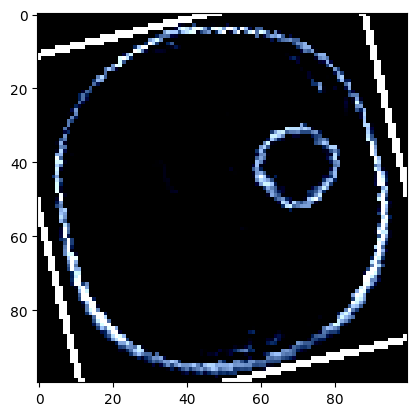

Label: 1


In [214]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.permute(1, 2, 0)) # Permute to (H, W, C) for matplotlib
plt.show()
print(f"Label: {label}")

In [215]:
# trenowanie naszego modelu

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.757279  [   64/  202]
Test Error: 
 Accuracy: 60.8%, Avg loss: 0.678289 

Epoch 2
-------------------------------
loss: 0.666374  [   64/  202]
Test Error: 
 Accuracy: 60.8%, Avg loss: 0.662093 

Epoch 3
-------------------------------
loss: 0.654440  [   64/  202]
Test Error: 
 Accuracy: 64.7%, Avg loss: 0.616650 

Epoch 4
-------------------------------
loss: 0.629344  [   64/  202]
Test Error: 
 Accuracy: 60.8%, Avg loss: 0.620312 

Epoch 5
-------------------------------
loss: 0.604261  [   64/  202]
Test Error: 
 Accuracy: 62.7%, Avg loss: 0.618636 

Epoch 6
-------------------------------
loss: 0.575460  [   64/  202]
Test Error: 
 Accuracy: 68.6%, Avg loss: 0.574655 

Epoch 7
-------------------------------
loss: 0.583156  [   64/  202]
Test Error: 
 Accuracy: 72.5%, Avg loss: 0.561530 

Epoch 8
-------------------------------
loss: 0.549359  [   64/  202]
Test Error: 
 Accuracy: 62.7%, Avg loss: 0.669743 

Epoch 9
----------------

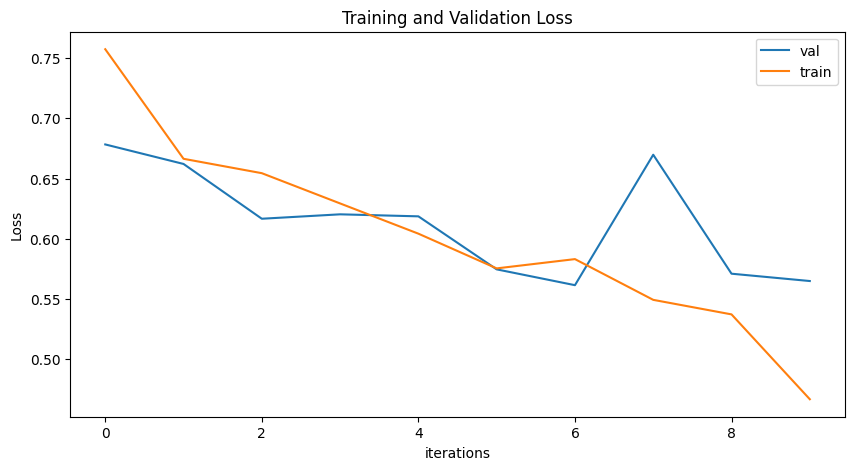

In [216]:
plt.figure(figsize=(10,5))
plt.title("Training and Validation Loss")
plt.plot(val_losses,label="val")
plt.plot(train_losses,label="train")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()